In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import ast

In [103]:
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [104]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [105]:
job_title = ['Data Analyst','Data Engineer','Data Scientist']
df_data_jobs = df[(df['job_country'] == 'United States') & df['job_title_short'].isin(job_title)]

In [106]:
df_data_jobs_exploded = df_data_jobs.explode('job_skills')

In [107]:
df_skills = df_data_jobs_exploded.groupby(['job_title_short','job_skills']).size().to_frame(name='skill_count')

In [113]:
df_skills=df_skills.sort_values(by='skill_count',ascending=False)
df_skills = df_skills.reset_index()

In [126]:
df_skills

,job_title_short,job_skills,skill_count
0,Data Scientist,python,42379
1,Data Analyst,sql,34452
2,Data Scientist,sql,30034
3,Data Analyst,excel,27519
4,Data Scientist,r,26022
...,...,...,...
662,Data Analyst,google chat,1
663,Data Scientist,symfony,1
664,Data Engineer,fastify,1
665,Data Analyst,capacitor,1


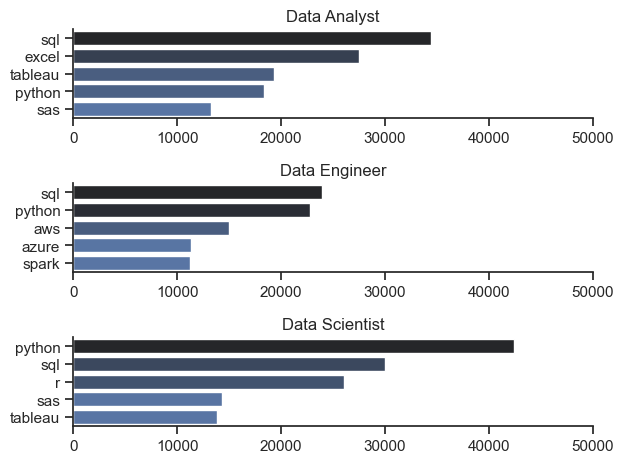

In [158]:
fig,ax = plt.subplots(len(job_title),1)
sns.set_theme(style="ticks")
sns.despine()
for i,title in enumerate(job_title):
    df_plot = df_skills[df_skills['job_title_short'] == title].head(5)
    sns.barplot(data=df_plot,x='skill_count',y='job_skills',ax=ax[i],hue='skill_count',palette='dark:b_r',legend=False)
    ax[i].set_title(title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0,50000)
    plt.tight_layout()

plt.show()

In [173]:
df_US= df[(df['job_country'] == 'United States')]
df_total_skill = df_US['job_title_short'].value_counts().reset_index()

In [174]:
df_total_skill

,job_title_short,count
0,Data Analyst,67816
1,Data Scientist,58830
2,Data Engineer,35080
3,Senior Data Scientist,12946
4,Senior Data Analyst,11791
5,Senior Data Engineer,9289
6,Business Analyst,7382
7,Software Engineer,1814
8,Machine Learning Engineer,921
9,Cloud Engineer,423


In [182]:
df_merge = pd.merge(df_skills,df_total_skill,on='job_title_short',how='left')

In [184]:
df_merge['skill_perc'] = df_merge['skill_count']/df_merge['count']*100

In [195]:
df_merge

,job_title_short,job_skills,skill_count,count,skill_perc
0,Data Scientist,python,42379,58830,72.036376
1,Data Analyst,sql,34452,67816,50.802171
2,Data Scientist,sql,30034,58830,51.052184
3,Data Analyst,excel,27519,67816,40.578919
4,Data Scientist,r,26022,58830,44.232534
...,...,...,...,...,...
662,Data Analyst,google chat,1,67816,0.001475
663,Data Scientist,symfony,1,58830,0.001700
664,Data Engineer,fastify,1,35080,0.002851
665,Data Analyst,capacitor,1,67816,0.001475


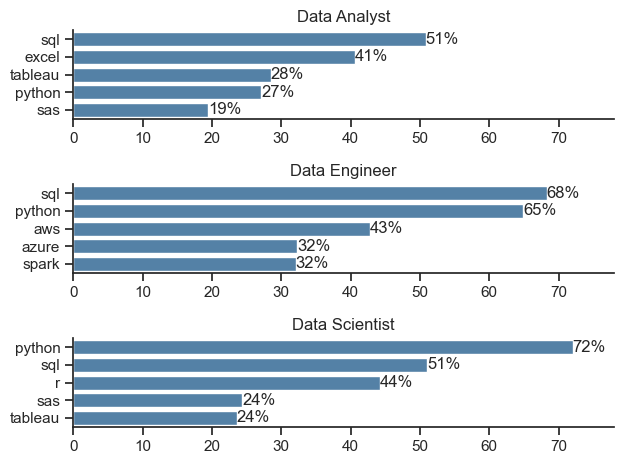

In [214]:
fig,ax = plt.subplots(3,1)
sns.despine()
for i,title in enumerate(job_title):
    df_plt = df_merge[df_merge['job_title_short'] == title].head(5)
    sns.barplot(data=df_plt,x='skill_perc',y='job_skills',ax=ax[i],color='steelblue')
    ax[i].set_title(title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0,78)

    for n,v in enumerate(df_plt['skill_perc']):
     ax[i].text(v,n,f'{v:.0f}%',va='center')

plt.tight_layout()